<div style="display: flex; align-items: center;">
  <div style="white-space: nowrap;">
    <img src="https://www.upc.edu/ca/@@images/6a7091d6-6f4a-4f70-a389-fc5fdf3a00ff.png" alt="Logo UPC" style="height:70px; display:inline-block; margin-right:20px;">
  </div>
  <div>
    <h1 style="margin-bottom:0;">End-to-End de Software con Modelo Predictivo</h1>
    <h2 style="margin-top:0;">Formulario + Pipeline + Predicción de Variable Respuesta</h2>
    <p><b>Contexto:</b> Auditoría bancaria, riesgo operativo y control interno</p>
  </div>
</div>

# 🧩 **End-to-End de Software Predictivo para Auditores Bancarios**

Este notebook construye un flujo completo de software: el auditor rellena un formulario, el sistema valida los datos, aplica un modelo entrenado y devuelve la **variable respuesta**.

**Caso de uso:** predicción del riesgo de una operación bancaria auditada.

**Variable respuesta:** `riesgo_alto`

- `0`: operación de riesgo normal/bajo.
- `1`: operación de riesgo alto que requiere revisión prioritaria.

El objetivo no es solo entrenar un modelo, sino integrarlo en una lógica de producto auditable, trazable y entendible para equipos de auditoría bancaria.

## 1. OBJETIVOS DEL NOTEBOOK

Al finalizar este notebook sabrás construir un flujo end-to-end con:

1. Generación/carga de datos bancarios.
2. Preparación de variables.
3. Entrenamiento de modelos candidatos.
4. Evaluación y selección del modelo final.
5. Guardado del pipeline completo.
6. Función de predicción para nuevos casos.
7. Formulario interactivo con `ipywidgets`.
8. Validación de datos de entrada.
9. Devolución de la variable respuesta.
10. Registro de predicciones para trazabilidad.
11. Plantillas para convertir el notebook en app con Streamlit o API con FastAPI.

## 2. CASO DE USO EN AUDITORÍA BANCARIA

Un equipo de auditoría quiere priorizar operaciones que podrían requerir revisión manual.

| Variable | Interpretación |
|---|---|
| `importe_operacion` | Importe de la operación |
| `antiguedad_cliente` | Meses desde el alta del cliente |
| `num_operaciones_30d` | Operaciones realizadas en los últimos 30 días |
| `ratio_efectivo` | Proporción de operaciones en efectivo |
| `pais_riesgo` | Operación vinculada a país de mayor riesgo |
| `alertas_previas` | Alertas previas asociadas al cliente |
| `documentacion_completa` | Si la documentación está completa |
| `canal` | Canal de ejecución de la operación |
| `segmento_cliente` | Segmento del cliente |
| `tipo_operacion` | Tipo de operación bancaria |
| `riesgo_alto` | Variable objetivo |

El software final simulará una pantalla donde el auditor introduce estos datos y recibe una predicción.

## 3. Arquitectura end-to-end

```text
Formulario del auditor
        ↓
Validación de entradas
        ↓
DataFrame de nuevo caso
        ↓
Pipeline de preprocesado
        ↓
Modelo entrenado
        ↓
Probabilidad estimada
        ↓
Clasificación final
        ↓
Explicación y acción recomendada
        ↓
Log de predicción
```

En entorno bancario no debe guardarse únicamente el modelo. Debe guardarse el **pipeline completo**, incluyendo imputación, codificación, escalado y modelo.

In [1]:
# ============================================================
# 1. Importación de librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

import joblib
from datetime import datetime

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    WIDGETS_AVAILABLE = True
except Exception:
    WIDGETS_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 4. Generación de datos sintéticos

En un proyecto real, estos datos vendrían de sistemas internos del banco: core banking, CRM, KYC, herramientas AML, expedientes de auditoría y alertas históricas.

Para que el notebook sea ejecutable sin dependencias externas, generaremos un dataset sintético.

In [2]:
# ============================================================
# 2. Dataset sintético de operaciones bancarias
# ============================================================
n = 4000

canales = ["oficina", "online", "movil", "cajero", "telefonica"]
segmentos = ["retail", "empresa", "patrimonial", "autonomo"]
tipos_operacion = ["transferencia", "retirada_efectivo", "ingreso_efectivo", "pago_tarjeta", "prestamo"]

importe_operacion = np.random.lognormal(mean=8.4, sigma=1.0, size=n)
antiguedad_cliente = np.random.randint(1, 240, size=n)
num_operaciones_30d = np.random.poisson(lam=18, size=n)
ratio_efectivo = np.clip(np.random.beta(a=2, b=5, size=n), 0, 1)
pais_riesgo = np.random.binomial(1, 0.12, size=n)
alertas_previas = np.random.poisson(lam=0.8, size=n)
documentacion_completa = np.random.binomial(1, 0.88, size=n)
canal = np.random.choice(canales, size=n, p=[0.25, 0.32, 0.25, 0.12, 0.06])
segmento_cliente = np.random.choice(segmentos, size=n, p=[0.58, 0.24, 0.08, 0.10])
tipo_operacion = np.random.choice(tipos_operacion, size=n, p=[0.42, 0.16, 0.12, 0.22, 0.08])

# Lógica latente de riesgo: combinación de patrones plausibles para auditoría
logit = (
    -4.2
    + 0.00009 * importe_operacion
    + 0.055 * num_operaciones_30d
    + 2.1 * ratio_efectivo
    + 1.2 * pais_riesgo
    + 0.75 * alertas_previas
    - 0.012 * antiguedad_cliente
    - 1.0 * documentacion_completa
    + np.where(canal == "cajero", 0.45, 0)
    + np.where(canal == "online", 0.25, 0)
    + np.where(segmento_cliente == "patrimonial", 0.35, 0)
    + np.where(tipo_operacion == "retirada_efectivo", 0.65, 0)
    + np.where(tipo_operacion == "ingreso_efectivo", 0.55, 0)
)

prob_riesgo = 1 / (1 + np.exp(-logit))
riesgo_alto = np.random.binomial(1, prob_riesgo)

df = pd.DataFrame({
    "importe_operacion": importe_operacion.round(2),
    "antiguedad_cliente": antiguedad_cliente,
    "num_operaciones_30d": num_operaciones_30d,
    "ratio_efectivo": ratio_efectivo.round(3),
    "pais_riesgo": pais_riesgo,
    "alertas_previas": alertas_previas,
    "documentacion_completa": documentacion_completa,
    "canal": canal,
    "segmento_cliente": segmento_cliente,
    "tipo_operacion": tipo_operacion,
    "riesgo_alto": riesgo_alto
})

df.head()

,importe_operacion,antiguedad_cliente,num_operaciones_30d,ratio_efectivo,pais_riesgo,alertas_previas,documentacion_completa,canal,segmento_cliente,tipo_operacion,riesgo_alto
0,7307.92,152,17,0.511,0,1,0,oficina,empresa,transferencia,1
1,3872.81,51,17,0.333,0,1,1,online,retail,transferencia,1
2,8498.87,10,22,0.283,1,2,1,oficina,empresa,pago_tarjeta,1
3,20394.69,120,12,0.405,0,0,1,online,empresa,ingreso_efectivo,0
4,3518.70,200,15,0.293,0,0,1,oficina,empresa,pago_tarjeta,0


## 5. Exploración inicial

Antes de automatizar una decisión, el auditor debe revisar:

- Tipos de variables.
- Valores perdidos.
- Distribución de la variable objetivo.
- Posibles desbalances.
- Rango de variables numéricas.
- Categorías existentes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   importe_operacion       4000 non-null   float64
 1   antiguedad_cliente      4000 non-null   int32  
 2   num_operaciones_30d     4000 non-null   int32  
 3   ratio_efectivo          4000 non-null   float64
 4   pais_riesgo             4000 non-null   int32  
 5   alertas_previas         4000 non-null   int32  
 6   documentacion_completa  4000 non-null   int32  
 7   canal                   4000 non-null   object 
 8   segmento_cliente        4000 non-null   object 
 9   tipo_operacion          4000 non-null   object 
 10  riesgo_alto             4000 non-null   int32  
dtypes: float64(2), int32(6), object(3)
memory usage: 250.1+ KB


In [4]:
df["riesgo_alto"].value_counts(normalize=True).rename("proporcion")

riesgo_alto
0    0.9075
1    0.0925
Name: proporcion, dtype: float64

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
importe_operacion,4000.0,NaN,NaN,NaN,7498.077537,10299.991695,173.94,2317.7225,4540.72,8716.2275,225536.59
antiguedad_cliente,4000.0,NaN,NaN,NaN,119.56675,68.609423,1.0,61.0,118.0,179.0,239.0
num_operaciones_30d,4000.0,NaN,NaN,NaN,18.063,4.249711,4.0,15.0,18.0,21.0,35.0
ratio_efectivo,4000.0,NaN,NaN,NaN,0.285913,0.15666,0.005,0.16,0.27,0.391,0.866
pais_riesgo,4000.0,NaN,NaN,NaN,0.11875,0.323535,0.0,0.0,0.0,0.0,1.0
alertas_previas,4000.0,NaN,NaN,NaN,0.8265,0.923369,0.0,0.0,1.0,1.0,6.0
documentacion_completa,4000.0,NaN,NaN,NaN,0.88375,0.320565,0.0,1.0,1.0,1.0,1.0
canal,4000,5,online,1279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segmento_cliente,4000,4,retail,2290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_operacion,4000,5,transferencia,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Separación train/test

La variable respuesta será `riesgo_alto`. La separación se hace con estratificación para mantener la proporción de casos positivos y negativos.

In [6]:
X = df.drop(columns=["riesgo_alto"])
y = df["riesgo_alto"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Proporción riesgo alto train:", round(y_train.mean(), 3))
print("Proporción riesgo alto test:", round(y_test.mean(), 3))

Train: (3000, 10)
Test: (1000, 10)
Proporción riesgo alto train: 0.093
Proporción riesgo alto test: 0.092


## 7. Pipeline de preprocesado

El pipeline transforma los datos brutos del formulario en datos aptos para el modelo.

- Variables numéricas: imputación por mediana y escalado.
- Variables categóricas: imputación por moda y One-Hot Encoding.

`handle_unknown="ignore"` evita errores si en producción aparece una categoría no vista durante el entrenamiento.

In [7]:
numeric_features = [
    "importe_operacion", "antiguedad_cliente", "num_operaciones_30d",
    "ratio_efectivo", "pais_riesgo", "alertas_previas",
    "documentacion_completa"
]

categorical_features = ["canal", "segmento_cliente", "tipo_operacion"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 8. Entrenamiento de modelos candidatos

Entrenaremos varios modelos para simular una fase de selección:

1. Regresión logística: baseline interpretable.
2. Gradient Boosting: modelo no lineal.
3. Random Forest: modelo robusto y relativamente estable.

En auditoría bancaria se deben considerar especialmente `recall`, `precision`, `F1` y `ROC AUC`. El accuracy por sí solo puede ser engañoso.

In [8]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

resultados = []
pipelines = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })
    pipelines[nombre] = pipe

resultados_df = pd.DataFrame(resultados).sort_values("roc_auc", ascending=False)
resultados_df

,modelo,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.768,0.253521,0.782609,0.382979,0.843612
2,Random Forest,0.849,0.309677,0.521739,0.388664,0.811818
1,Gradient Boosting,0.907,0.476190,0.108696,0.176991,0.791988


## 9. Selección y evaluación del modelo final

Seleccionaremos el modelo con mayor `ROC AUC`. En una entidad bancaria real, la elección final debería validarse también con criterios de gobierno del modelo, interpretabilidad, estabilidad y coste operativo de las alertas.

In [9]:
mejor_modelo_nombre = resultados_df.iloc[0]["modelo"]
modelo_final = pipelines[mejor_modelo_nombre]

print("Modelo final seleccionado:", mejor_modelo_nombre)

y_pred = modelo_final.predict(X_test)
y_prob = modelo_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Riesgo normal", "Riesgo alto"]))

Modelo final seleccionado: Logistic Regression
               precision    recall  f1-score   support

Riesgo normal       0.97      0.77      0.86       908
  Riesgo alto       0.25      0.78      0.38        92

     accuracy                           0.77      1000
    macro avg       0.61      0.77      0.62      1000
 weighted avg       0.91      0.77      0.81      1000



In [10]:
cm = confusion_matrix(y_test, y_pred)
pd.DataFrame(
    cm,
    index=["Real normal", "Real alto"],
    columns=["Predicho normal", "Predicho alto"]
)

,Predicho normal,Predicho alto
Real normal,696,212
Real alto,20,72


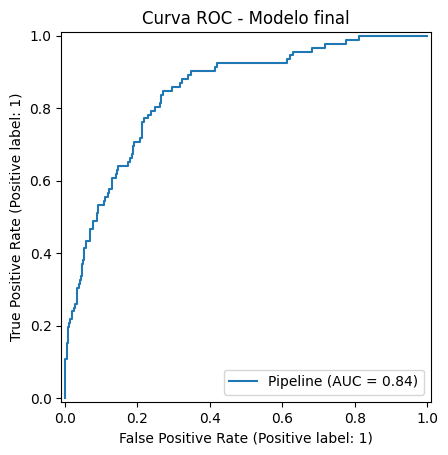

In [11]:
RocCurveDisplay.from_estimator(modelo_final, X_test, y_test)
plt.title("Curva ROC - Modelo final")
plt.show()

## 10. Umbral de decisión

El umbral por defecto suele ser 0.50, pero en auditoría puede interesar modificarlo:

- Umbral bajo: más casos revisados, mayor recall, más falsos positivos.
- Umbral alto: menos carga de revisión, más riesgo de dejar pasar casos relevantes.

In [12]:
def evaluar_umbral(y_true, y_prob, umbral):
    y_pred_umbral = (y_prob >= umbral).astype(int)
    return {
        "umbral": umbral,
        "precision": precision_score(y_true, y_pred_umbral, zero_division=0),
        "recall": recall_score(y_true, y_pred_umbral, zero_division=0),
        "f1": f1_score(y_true, y_pred_umbral, zero_division=0),
        "alertas_generadas_%": round(100 * y_pred_umbral.mean(), 2)
    }

pd.DataFrame([evaluar_umbral(y_test, y_prob, u) for u in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]])

,umbral,precision,recall,f1,alertas_generadas_%
0,0.2,0.132018,0.945652,0.231691,65.9
1,0.3,0.170000,0.923913,0.287162,50.0
2,0.4,0.213904,0.869565,0.343348,37.4
3,0.5,0.253521,0.782609,0.382979,28.4
4,0.6,0.292079,0.641304,0.401361,20.2
5,0.7,0.350000,0.532609,0.422414,14.0


## 11. Guardado y carga del pipeline

Este paso es clave para convertir el notebook en software. Guardamos el pipeline completo y después lo cargamos como si estuviéramos en producción.

In [13]:
ruta_modelo = "modelo_riesgo_auditoria_bancaria.joblib"
joblib.dump(modelo_final, ruta_modelo)
print(f"Pipeline guardado en: {ruta_modelo}")

modelo_produccion = joblib.load(ruta_modelo)
print("Modelo cargado correctamente.")

Pipeline guardado en: modelo_riesgo_auditoria_bancaria.joblib
Modelo cargado correctamente.


## 12. Función central de predicción

Esta función recibe los datos del formulario, crea un `DataFrame`, aplica el modelo y devuelve la variable respuesta.

In [14]:
def predecir_riesgo_operacion(
    importe_operacion,
    antiguedad_cliente,
    num_operaciones_30d,
    ratio_efectivo,
    pais_riesgo,
    alertas_previas,
    documentacion_completa,
    canal,
    segmento_cliente,
    tipo_operacion,
    umbral=0.50,
    modelo=modelo_produccion
):
    nuevo_caso = pd.DataFrame([{
        "importe_operacion": importe_operacion,
        "antiguedad_cliente": antiguedad_cliente,
        "num_operaciones_30d": num_operaciones_30d,
        "ratio_efectivo": ratio_efectivo,
        "pais_riesgo": int(pais_riesgo),
        "alertas_previas": alertas_previas,
        "documentacion_completa": int(documentacion_completa),
        "canal": canal,
        "segmento_cliente": segmento_cliente,
        "tipo_operacion": tipo_operacion
    }])
    
    probabilidad = modelo.predict_proba(nuevo_caso)[:, 1][0]
    clase = int(probabilidad >= umbral)
    
    resultado = {
        "probabilidad_riesgo_alto": round(float(probabilidad), 4),
        "umbral_decision": umbral,
        "clase_predicha": clase,
        "variable_respuesta": "riesgo_alto" if clase == 1 else "riesgo_normal_bajo",
        "interpretacion": "RIESGO ALTO: revisión prioritaria" if clase == 1 else "RIESGO NORMAL/BAJO: monitorización ordinaria"
    }
    
    return nuevo_caso, resultado

In [15]:
caso, resultado = predecir_riesgo_operacion(
    importe_operacion=18500,
    antiguedad_cliente=8,
    num_operaciones_30d=42,
    ratio_efectivo=0.72,
    pais_riesgo=1,
    alertas_previas=3,
    documentacion_completa=0,
    canal="online",
    segmento_cliente="patrimonial",
    tipo_operacion="retirada_efectivo",
    umbral=0.40
)

display(caso)
resultado

,importe_operacion,antiguedad_cliente,num_operaciones_30d,ratio_efectivo,pais_riesgo,alertas_previas,documentacion_completa,canal,segmento_cliente,tipo_operacion
0,18500,8,42,0.72,1,3,0,online,patrimonial,retirada_efectivo


{'probabilidad_riesgo_alto': 0.9996,
 'umbral_decision': 0.4,
 'clase_predicha': 1,
 'variable_respuesta': 'riesgo_alto',
 'interpretacion': 'RIESGO ALTO: revisión prioritaria'}

## 13. Formulario interactivo en Jupyter

El siguiente bloque crea un formulario con `ipywidgets`. Al pulsar el botón, se aplica el modelo y se muestra la variable respuesta.

In [16]:
if WIDGETS_AVAILABLE:
    importe_widget = widgets.FloatText(value=10000, description="Importe (€):")
    antiguedad_widget = widgets.IntText(value=36, description="Antigüedad:")
    operaciones_widget = widgets.IntText(value=15, description="Ops 30d:")
    ratio_widget = widgets.FloatSlider(value=0.25, min=0, max=1, step=0.01, description="Ratio efectivo:")
    pais_widget = widgets.Dropdown(options=[("No", 0), ("Sí", 1)], value=0, description="País riesgo:")
    alertas_widget = widgets.IntText(value=0, description="Alertas previas:")
    doc_widget = widgets.Dropdown(options=[("Completa", 1), ("Incompleta", 0)], value=1, description="Documentación:")
    canal_widget = widgets.Dropdown(options=canales, value="online", description="Canal:")
    segmento_widget = widgets.Dropdown(options=segmentos, value="retail", description="Segmento:")
    tipo_widget = widgets.Dropdown(options=tipos_operacion, value="transferencia", description="Tipo op.:")
    umbral_widget = widgets.FloatSlider(value=0.50, min=0.05, max=0.95, step=0.05, description="Umbral:")
    boton = widgets.Button(description="Predecir riesgo", button_style="warning")
    salida = widgets.Output()
    
    def on_button_clicked(b):
        with salida:
            clear_output()
            caso, resultado = predecir_riesgo_operacion(
                importe_widget.value,
                antiguedad_widget.value,
                operaciones_widget.value,
                ratio_widget.value,
                pais_widget.value,
                alertas_widget.value,
                doc_widget.value,
                canal_widget.value,
                segmento_widget.value,
                tipo_widget.value,
                umbral_widget.value
            )
            print("DATOS INTRODUCIDOS")
            display(caso)
            print("RESULTADO DEL MODELO")
            display(pd.DataFrame([resultado]))
            
    boton.on_click(on_button_clicked)
    
    display(widgets.VBox([
        widgets.HTML("<h3>Formulario de predicción de riesgo de operación bancaria</h3>"),
        importe_widget, antiguedad_widget, operaciones_widget, ratio_widget,
        pais_widget, alertas_widget, doc_widget, canal_widget,
        segmento_widget, tipo_widget, umbral_widget, boton, salida
    ]))
else:
    print("ipywidgets no está disponible en este entorno.")

ipywidgets no está disponible en este entorno.


## 14. Validación de entradas

Un software bancario debe validar los campos antes de llamar al modelo. Esto evita predicciones incoherentes y facilita auditoría del sistema.

In [17]:
def validar_entrada_operacion(datos):
    errores = []
    if datos["importe_operacion"] < 0:
        errores.append("El importe de la operación no puede ser negativo.")
    if datos["antiguedad_cliente"] < 0:
        errores.append("La antigüedad del cliente no puede ser negativa.")
    if datos["num_operaciones_30d"] < 0:
        errores.append("El número de operaciones no puede ser negativo.")
    if not (0 <= datos["ratio_efectivo"] <= 1):
        errores.append("El ratio de efectivo debe estar entre 0 y 1.")
    if datos["canal"] not in canales:
        errores.append("Canal no reconocido.")
    if datos["segmento_cliente"] not in segmentos:
        errores.append("Segmento no reconocido.")
    if datos["tipo_operacion"] not in tipos_operacion:
        errores.append("Tipo de operación no reconocido.")
    return errores

datos_erroneos = {
    "importe_operacion": -100,
    "antiguedad_cliente": 10,
    "num_operaciones_30d": 5,
    "ratio_efectivo": 1.2,
    "canal": "online",
    "segmento_cliente": "retail",
    "tipo_operacion": "transferencia"
}

validar_entrada_operacion(datos_erroneos)

['El importe de la operación no puede ser negativo.',
 'El ratio de efectivo debe estar entre 0 y 1.']

## 15. Función de software final

Integramos validación, predicción, explicación y salida final.

In [18]:
def explicacion_negocio(datos):
    razones = []
    if datos["importe_operacion"] > 20000:
        razones.append("importe elevado")
    if datos["num_operaciones_30d"] > 40:
        razones.append("volumen alto de operaciones recientes")
    if datos["ratio_efectivo"] > 0.60:
        razones.append("alta proporción de efectivo")
    if datos["pais_riesgo"] == 1:
        razones.append("país de riesgo")
    if datos["alertas_previas"] >= 2:
        razones.append("alertas previas")
    if datos["documentacion_completa"] == 0:
        razones.append("documentación incompleta")
    if datos["tipo_operacion"] in ["retirada_efectivo", "ingreso_efectivo"]:
        razones.append("operación intensiva en efectivo")
    return "Factores relevantes: " + ", ".join(razones) if razones else "Sin señales de negocio especialmente destacadas."

def software_prediccion_auditoria(datos_formulario, umbral=0.50):
    errores = validar_entrada_operacion(datos_formulario)
    if errores:
        return {"estado": "error_validacion", "errores": errores}
    
    _, resultado = predecir_riesgo_operacion(
        datos_formulario["importe_operacion"],
        datos_formulario["antiguedad_cliente"],
        datos_formulario["num_operaciones_30d"],
        datos_formulario["ratio_efectivo"],
        datos_formulario["pais_riesgo"],
        datos_formulario["alertas_previas"],
        datos_formulario["documentacion_completa"],
        datos_formulario["canal"],
        datos_formulario["segmento_cliente"],
        datos_formulario["tipo_operacion"],
        umbral=umbral
    )
    
    return {
        "estado": "ok",
        "probabilidad_riesgo_alto": resultado["probabilidad_riesgo_alto"],
        "variable_respuesta": resultado["variable_respuesta"],
        "clase_predicha": resultado["clase_predicha"],
        "interpretacion_modelo": resultado["interpretacion"],
        "explicacion_negocio": explicacion_negocio(datos_formulario),
        "accion_recomendada": "Revisión manual prioritaria" if resultado["clase_predicha"] == 1 else "Monitorización ordinaria"
    }

In [19]:
datos_formulario = {
    "importe_operacion": 32000,
    "antiguedad_cliente": 5,
    "num_operaciones_30d": 55,
    "ratio_efectivo": 0.81,
    "pais_riesgo": 1,
    "alertas_previas": 4,
    "documentacion_completa": 0,
    "canal": "cajero",
    "segmento_cliente": "empresa",
    "tipo_operacion": "ingreso_efectivo"
}

software_prediccion_auditoria(datos_formulario, umbral=0.40)

{'estado': 'ok',
 'probabilidad_riesgo_alto': 1.0,
 'variable_respuesta': 'riesgo_alto',
 'clase_predicha': 1,
 'interpretacion_modelo': 'RIESGO ALTO: revisión prioritaria',
 'explicacion_negocio': 'Factores relevantes: importe elevado, volumen alto de operaciones recientes, alta proporción de efectivo, país de riesgo, alertas previas, documentación incompleta, operación intensiva en efectivo',
 'accion_recomendada': 'Revisión manual prioritaria'}

## 16. Importancia de variables

Si el modelo permite extraer importancias o coeficientes, podemos revisar qué variables influyen más globalmente. Esto no sustituye una explicación local tipo SHAP, pero ayuda a entender el comportamiento general.

In [20]:
preprocessor_fitted = modelo_final.named_steps["preprocessor"]
model_fitted = modelo_final.named_steps["model"]

try:
    feature_names = preprocessor_fitted.get_feature_names_out()
    if hasattr(model_fitted, "feature_importances_"):
        imp_df = pd.DataFrame({
            "variable_transformada": feature_names,
            "importancia": model_fitted.feature_importances_
        }).sort_values("importancia", ascending=False)
        display(imp_df.head(20))
    elif hasattr(model_fitted, "coef_"):
        coef_df = pd.DataFrame({
            "variable_transformada": feature_names,
            "coeficiente": model_fitted.coef_[0],
            "abs_coeficiente": np.abs(model_fitted.coef_[0])
        }).sort_values("abs_coeficiente", ascending=False)
        display(coef_df.head(20))
    else:
        print("El modelo no expone importancias directamente.")
except Exception as e:
    print("No se pudieron obtener importancias:", e)

,variable_transformada,coeficiente,abs_coeficiente
0,num__importe_operacion,0.829438,0.829438
1,num__antiguedad_cliente,-0.779911,0.779911
7,cat__canal_cajero,0.743764,0.743764
18,cat__tipo_operacion_prestamo,-0.727713,0.727713
11,cat__canal_telefonica,-0.714648,0.714648
16,cat__tipo_operacion_ingreso_efectivo,0.653255,0.653255
5,num__alertas_previas,0.648255,0.648255
9,cat__canal_oficina,-0.467634,0.467634
4,num__pais_riesgo,0.352844,0.352844
12,cat__segmento_cliente_autonomo,-0.327416,0.327416


## 17. Log de predicciones

En auditoría bancaria debe existir trazabilidad. Cada predicción debería guardar:

- Fecha y hora.
- Usuario.
- Versión/modelo usado.
- Datos introducidos.
- Resultado.
- Acción recomendada.

In [21]:
log_predicciones = []

def registrar_prediccion(usuario, datos_formulario, resultado):
    log = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "usuario": usuario,
        "modelo": mejor_modelo_nombre,
        **datos_formulario,
        **resultado
    }
    log_predicciones.append(log)
    return log

resultado = software_prediccion_auditoria(datos_formulario, umbral=0.40)
registrar_prediccion("auditor_001", datos_formulario, resultado)

pd.DataFrame(log_predicciones)

,timestamp,usuario,modelo,importe_operacion,antiguedad_cliente,num_operaciones_30d,ratio_efectivo,pais_riesgo,alertas_previas,documentacion_completa,canal,segmento_cliente,tipo_operacion,estado,probabilidad_riesgo_alto,variable_respuesta,clase_predicha,interpretacion_modelo,explicacion_negocio,accion_recomendada
0,2026-04-28T12:32:05,auditor_001,Logistic Regression,32000,5,55,0.81,1,4,0,cajero,empresa,ingreso_efectivo,ok,1.0,riesgo_alto,1,RIESGO ALTO: revisión prioritaria,"Factores relevantes: importe elevado, volumen ...",Revisión manual prioritaria


In [22]:
log_df = pd.DataFrame(log_predicciones)
log_df.to_csv("log_predicciones_auditoria.csv", index=False)
print("Log exportado correctamente.")

Log exportado correctamente.


## 18. Plantilla para app Streamlit

El siguiente código puede guardarse como `app.py` para crear una interfaz web simple.

In [23]:
codigo_streamlit = """
import streamlit as st
import pandas as pd
import joblib

modelo = joblib.load('modelo_riesgo_auditoria_bancaria.joblib')

st.title('Predicción de Riesgo de Operación Bancaria')

importe_operacion = st.number_input('Importe de la operación (€)', min_value=0.0, value=10000.0)
antiguedad_cliente = st.number_input('Antigüedad del cliente en meses', min_value=0, value=36)
num_operaciones_30d = st.number_input('Número de operaciones en últimos 30 días', min_value=0, value=15)
ratio_efectivo = st.slider('Ratio de efectivo', min_value=0.0, max_value=1.0, value=0.25)
pais_riesgo = st.selectbox('País de riesgo', [0, 1], format_func=lambda x: 'Sí' if x == 1 else 'No')
alertas_previas = st.number_input('Alertas previas', min_value=0, value=0)
documentacion_completa = st.selectbox('Documentación completa', [1, 0], format_func=lambda x: 'Completa' if x == 1 else 'Incompleta')
canal = st.selectbox('Canal', ['oficina', 'online', 'movil', 'cajero', 'telefonica'])
segmento_cliente = st.selectbox('Segmento', ['retail', 'empresa', 'patrimonial', 'autonomo'])
tipo_operacion = st.selectbox('Tipo de operación', ['transferencia', 'retirada_efectivo', 'ingreso_efectivo', 'pago_tarjeta', 'prestamo'])
umbral = st.slider('Umbral de decisión', min_value=0.05, max_value=0.95, value=0.50)

if st.button('Predecir'):
    nuevo_caso = pd.DataFrame([{
        'importe_operacion': importe_operacion,
        'antiguedad_cliente': antiguedad_cliente,
        'num_operaciones_30d': num_operaciones_30d,
        'ratio_efectivo': ratio_efectivo,
        'pais_riesgo': pais_riesgo,
        'alertas_previas': alertas_previas,
        'documentacion_completa': documentacion_completa,
        'canal': canal,
        'segmento_cliente': segmento_cliente,
        'tipo_operacion': tipo_operacion
    }])
    prob = modelo.predict_proba(nuevo_caso)[:, 1][0]
    clase = int(prob >= umbral)
    st.write(f'Probabilidad de riesgo alto: {prob:.3f}')
    if clase == 1:
        st.error('RIESGO ALTO: revisión prioritaria recomendada')
    else:
        st.success('RIESGO NORMAL/BAJO: monitorización ordinaria')
"""
print(codigo_streamlit)


import streamlit as st
import pandas as pd
import joblib

modelo = joblib.load('modelo_riesgo_auditoria_bancaria.joblib')

st.title('Predicción de Riesgo de Operación Bancaria')

importe_operacion = st.number_input('Importe de la operación (€)', min_value=0.0, value=10000.0)
antiguedad_cliente = st.number_input('Antigüedad del cliente en meses', min_value=0, value=36)
num_operaciones_30d = st.number_input('Número de operaciones en últimos 30 días', min_value=0, value=15)
ratio_efectivo = st.slider('Ratio de efectivo', min_value=0.0, max_value=1.0, value=0.25)
pais_riesgo = st.selectbox('País de riesgo', [0, 1], format_func=lambda x: 'Sí' if x == 1 else 'No')
alertas_previas = st.number_input('Alertas previas', min_value=0, value=0)
documentacion_completa = st.selectbox('Documentación completa', [1, 0], format_func=lambda x: 'Completa' if x == 1 else 'Incompleta')
canal = st.selectbox('Canal', ['oficina', 'online', 'movil', 'cajero', 'telefonica'])
segmento_cliente = st.selectbox('Segm

## 19. Plantilla para API FastAPI

Si el modelo debe integrarse con sistemas internos, una API puede ser más adecuada.

In [24]:
codigo_fastapi = """
from fastapi import FastAPI
from pydantic import BaseModel, Field
import pandas as pd
import joblib

app = FastAPI(title='API de Predicción de Riesgo Bancario')
modelo = joblib.load('modelo_riesgo_auditoria_bancaria.joblib')

class OperacionBancaria(BaseModel):
    importe_operacion: float = Field(..., ge=0)
    antiguedad_cliente: int = Field(..., ge=0)
    num_operaciones_30d: int = Field(..., ge=0)
    ratio_efectivo: float = Field(..., ge=0, le=1)
    pais_riesgo: int = Field(..., ge=0, le=1)
    alertas_previas: int = Field(..., ge=0)
    documentacion_completa: int = Field(..., ge=0, le=1)
    canal: str
    segmento_cliente: str
    tipo_operacion: str
    umbral: float = Field(0.50, ge=0.05, le=0.95)

@app.post('/predecir')
def predecir(operacion: OperacionBancaria):
    datos = operacion.model_dump()
    umbral = datos.pop('umbral')
    X = pd.DataFrame([datos])
    prob = modelo.predict_proba(X)[:, 1][0]
    clase = int(prob >= umbral)
    return {
        'probabilidad_riesgo_alto': round(float(prob), 4),
        'clase_predicha': clase,
        'variable_respuesta': 'riesgo_alto' if clase == 1 else 'riesgo_normal_bajo'
    }
"""
print(codigo_fastapi)


from fastapi import FastAPI
from pydantic import BaseModel, Field
import pandas as pd
import joblib

app = FastAPI(title='API de Predicción de Riesgo Bancario')
modelo = joblib.load('modelo_riesgo_auditoria_bancaria.joblib')

class OperacionBancaria(BaseModel):
    importe_operacion: float = Field(..., ge=0)
    antiguedad_cliente: int = Field(..., ge=0)
    num_operaciones_30d: int = Field(..., ge=0)
    ratio_efectivo: float = Field(..., ge=0, le=1)
    pais_riesgo: int = Field(..., ge=0, le=1)
    alertas_previas: int = Field(..., ge=0)
    documentacion_completa: int = Field(..., ge=0, le=1)
    canal: str
    segmento_cliente: str
    tipo_operacion: str
    umbral: float = Field(0.50, ge=0.05, le=0.95)

@app.post('/predecir')
def predecir(operacion: OperacionBancaria):
    datos = operacion.model_dump()
    umbral = datos.pop('umbral')
    X = pd.DataFrame([datos])
    prob = modelo.predict_proba(X)[:, 1][0]
    clase = int(prob >= umbral)
    return {
        'probabilidad_ries

## 20. Controles necesarios en entorno bancario

| Área | Control necesario |
|---|---|
| Gobierno del modelo | Versión, propietario, fecha de entrenamiento |
| Calidad de datos | Validación de rangos, nulos y categorías |
| Trazabilidad | Registro de inputs, outputs, usuario y fecha |
| Seguridad | Control de acceso y protección de datos sensibles |
| Auditoría | Logs de predicción y justificación de uso |
| Monitorización | Drift de datos y caída de rendimiento |
| Explicabilidad | Variables relevantes y razones de negocio |
| Reentrenamiento | Política clara de actualización del modelo |
| Cumplimiento | Revisión legal, compliance y gestión del riesgo de modelo |

## 21. Errores comunes al pasar de notebook a software

| Error | Consecuencia |
|---|---|
| Guardar solo el modelo y no el pipeline | Fallos al predecir con datos nuevos |
| No validar datos del formulario | Predicciones absurdas o errores silenciosos |
| Cambiar nombres de variables | El modelo no reconoce las columnas |
| No controlar categorías nuevas | Error en codificación categórica |
| Usar accuracy como única métrica | Modelo poco útil para auditoría |
| No guardar logs | Falta de trazabilidad |
| No versionar el modelo | Imposibilidad de reproducir resultados |
| No definir umbral de decisión | Alertas mal calibradas |
| No explicar la salida | Baja confianza del auditor |

# 22. Ejercicios propuestos

A continuación se proponen 10 ejercicios finales para practicar con nuevos datos y nuevas casuísticas.

## Ejercicio 1

Añade una variable `cliente_pep` que indique si el cliente es persona políticamente expuesta. Reentrena el modelo y analiza su importancia.

## Ejercicio 2

Cambia la variable respuesta a `fraude_confirmado` y define una nueva lógica sintética para generarla.

## Ejercicio 3

Añade la variable categórica `zona_geografica` con valores `nacional`, `ue`, `latam`, `asia` y `otros`.

## Ejercicio 4

Entrena un modelo XGBoost o CatBoost y compara sus métricas con los modelos actuales.

## Ejercicio 5

Crea tres niveles de prioridad: baja, media y alta según la probabilidad predicha.

## Ejercicio 6

Incorpora SHAP para explicar predicciones individuales de riesgo alto y riesgo bajo.

## Ejercicio 7

Crea una función que reciba un CSV con operaciones nuevas y devuelva otro CSV con predicciones.

## Ejercicio 8

Convierte el formulario de Jupyter en una app de Streamlit funcional.

## Ejercicio 9

Amplía el sistema de logs para guardar versión del modelo, usuario, fecha y acción tomada.

## Ejercicio 10

Simula drift de datos aumentando importes y ratio de efectivo. Compara las distribuciones y discute si hace falta reentrenar.

# 23. Plantilla base de entrega

El alumno debería entregar:

1. Notebook ejecutado.
2. Descripción del caso de uso.
3. Dataset usado o generado.
4. Métricas del modelo.
5. Captura del formulario funcionando.
6. Ejemplo de predicción de riesgo alto.
7. Ejemplo de predicción de riesgo bajo.
8. Explicación de variables relevantes.
9. Propuesta de despliegue.
10. Discusión de controles necesarios en contexto bancario.